In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import joblib

df = pd.read_csv("../outputs/soil_features_final.csv")

CLUSTER_FEATURES = ["awc", "organic_carbon", "cec", "ph", "bulk_density", "clay_pct", "sand_pct"]

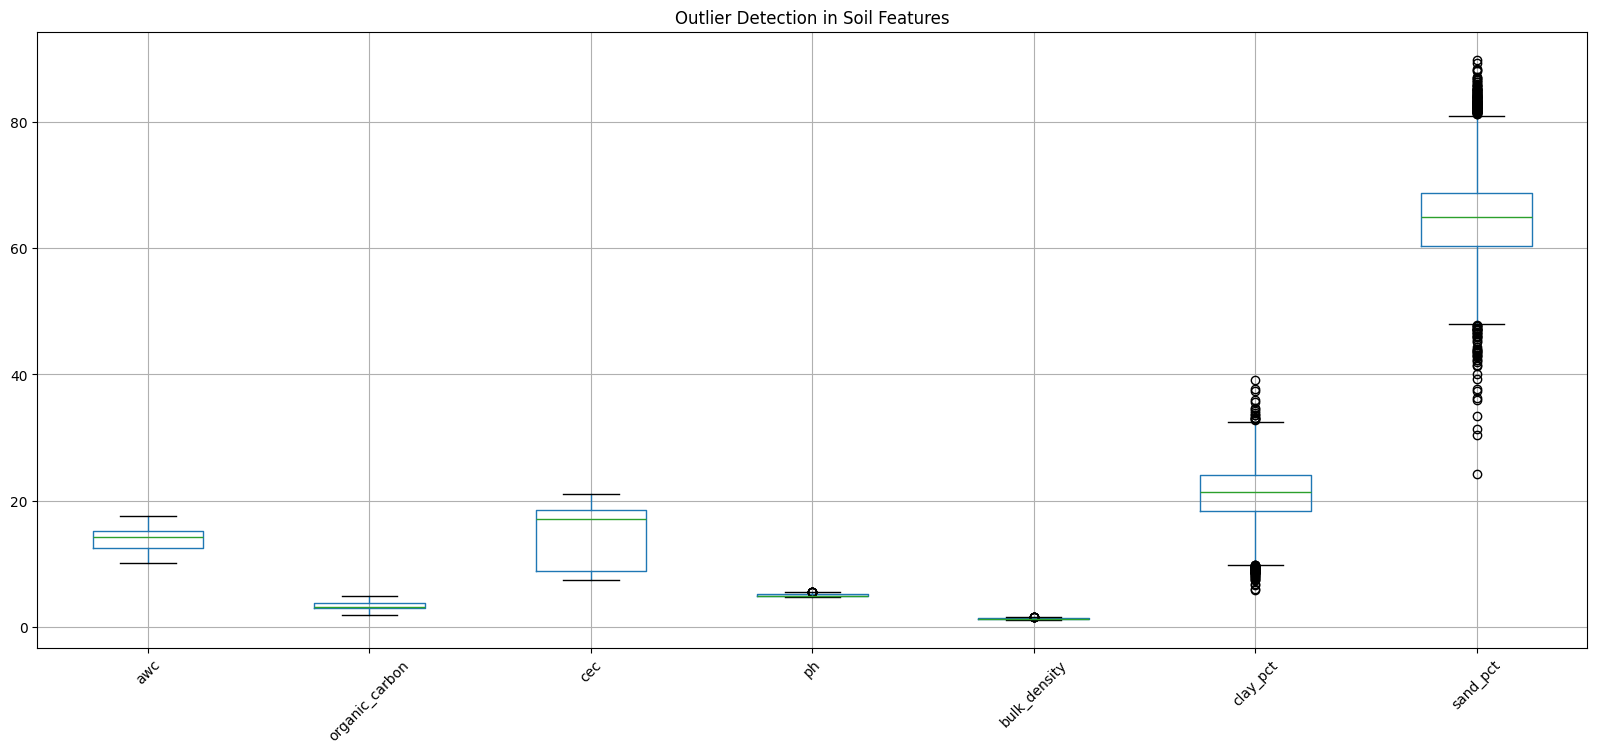

In [2]:
plt.figure(figsize=(20, 8))
df[CLUSTER_FEATURES].boxplot()
plt.title("Outlier Detection in Soil Features")
plt.xticks(rotation=45)
plt.show()

Outliers capped at 1st and 99th percentiles.


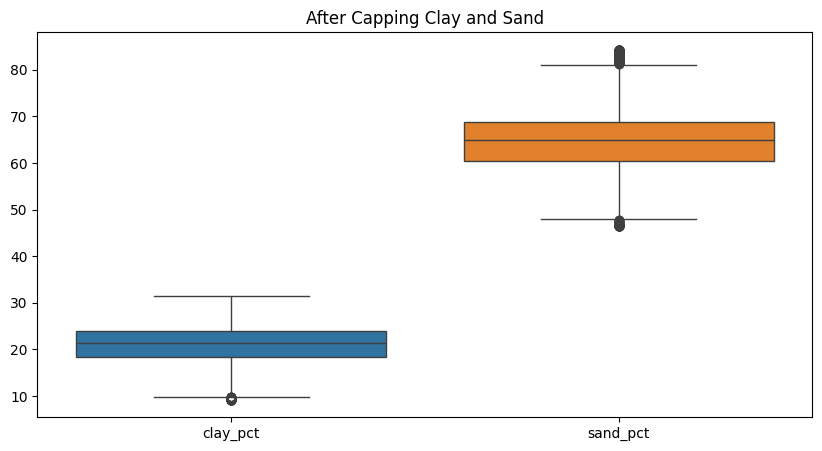

In [3]:
for feature in ['clay_pct', 'sand_pct']:
    lower_limit = df[feature].quantile(0.01)
    upper_limit = df[feature].quantile(0.99)
  
    df[feature] = df[feature].clip(lower_limit, upper_limit)

print("Outliers capped at 1st and 99th percentiles.")

plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['clay_pct', 'sand_pct']])
plt.title("After Capping Clay and Sand")
plt.show()

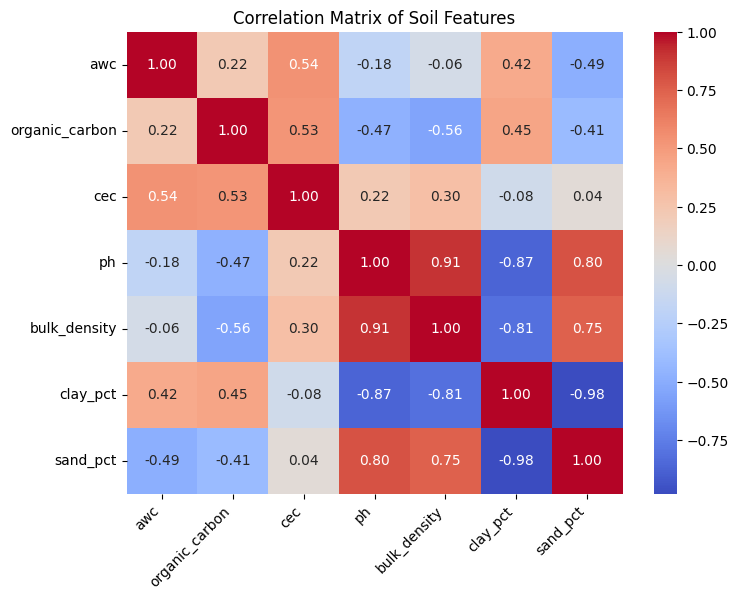

In [4]:
plt.figure(figsize=(8, 6))
corr_matrix = df[CLUSTER_FEATURES].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.title("Correlation Matrix of Soil Features")
plt.show()

In [5]:
FINAL_CLUSTER_FEATURES = ["awc", "organic_carbon", "cec", "ph", "bulk_density", "sand_pct"]

print(f"Dropping 'clay_pct' due to high correlation (-0.98) with 'sand_pct'.")
print(f"Final features for clustering: {FINAL_CLUSTER_FEATURES}")

Dropping 'clay_pct' due to high correlation (-0.98) with 'sand_pct'.
Final features for clustering: ['awc', 'organic_carbon', 'cec', 'ph', 'bulk_density', 'sand_pct']


In [6]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df[FINAL_CLUSTER_FEATURES])

df_scaled = pd.DataFrame(scaled_data, columns=FINAL_CLUSTER_FEATURES)

df_scaled[['lat', 'lon', 'texture_class']] = df[['lat', 'lon', 'texture_class']]

print("Scaling complete. All features now have a mean of 0 and a standard deviation of 1.")

Scaling complete. All features now have a mean of 0 and a standard deviation of 1.


      awc  organic_carbon  cec   ph  bulk_density  sand_pct
mean  0.0            -0.0 -0.0 -0.0          -0.0       0.0
std   1.0             1.0  1.0  1.0           1.0       1.0


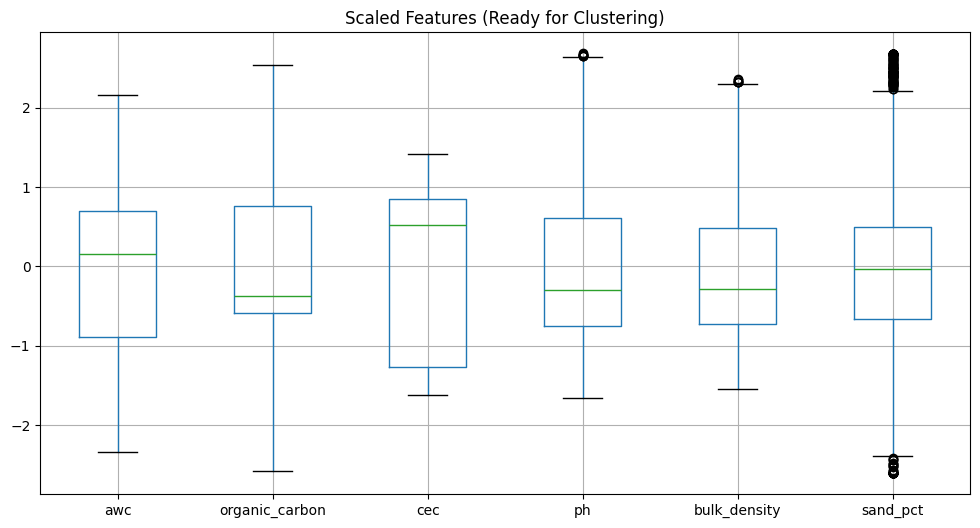

In [7]:
print(df_scaled[FINAL_CLUSTER_FEATURES].describe().round(2).loc[['mean', 'std']])

plt.figure(figsize=(12, 6))
df_scaled[FINAL_CLUSTER_FEATURES].boxplot()
plt.title("Scaled Features (Ready for Clustering)")
plt.show()

In [8]:
df_scaled.to_csv("../outputs/soil_features_scaled.csv", index=False)

joblib.dump(scaler, '../outputs/soil_scaler.pkl')

print("Success: Scaled data and Scaler object saved to ../outputs/")

Success: Scaled data and Scaler object saved to ../outputs/
